<div style="background:linear-gradient(135deg,#4a044e 0%,#a21caf 55%,#e879f9 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#f5d0fe;font-weight:700;text-transform:uppercase">Chapter 143 · Advanced &amp; Applied Topics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Causal Inference &middot; Challenge Solutions</div>
  <div style="font-size:15px;color:#fae8ff;max-width:740px;line-height:1.6">Worked solutions: show the confounding, naive vs adjusted, propensity scores, inverse-probability weighting, and the collider trap.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
FU, BL, GR, RD = "#a21caf", "#2563eb", "#16a34a", "#dc2626"
TRUE = 120     # the causal effect built into this simulated data
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "causal-inference--loyalty-program.xlsx"
try:
    df = pd.read_excel("../../data/" + fn)
except FileNotFoundError:
    df = pd.read_excel(BASE + fn)
print(df.shape); print(df.head())

(2000, 5)
  customer_id  prior_spend  tenure_months  enrolled   spend
0     C200000       202.39             42         0  294.92
1     C200001       295.18             39         1  631.32
2     C200002       285.73              7         1  564.11
3     C200003       164.28             14         0  327.24
4     C200004       179.14             48         0  373.30


## Challenge 1 &middot; Show the confounding
Enrolled customers differ on the confounders *before* treatment, so a raw comparison mixes the program's effect with those pre-existing differences.

In [2]:
print(df.groupby("enrolled")[["prior_spend", "tenure_months"]].mean().round(1))
print("Enrollees already spent more and had longer tenure -> the naive gap is inflated.")

          prior_spend  tenure_months
enrolled                            
0               181.0           28.4
1               243.7           36.9
Enrollees already spent more and had longer tenure -> the naive gap is inflated.


## Challenge 2 &middot; Naive vs adjusted
The naive difference and the regression-adjusted coefficient can differ enormously.

In [3]:
naive = df.loc[df.enrolled==1,"spend"].mean() - df.loc[df.enrolled==0,"spend"].mean()
reg = smf.ols("spend ~ enrolled + prior_spend + tenure_months", data=df).fit()
print(f"naive difference   = ${naive:.1f}")
print(f"adjusted (enrolled)= ${reg.params['enrolled']:.1f}   (true ${TRUE})")
print(f"the naive figure overstates the effect by ${naive-reg.params['enrolled']:.0f}")

naive difference   = $195.8
adjusted (enrolled)= $117.1   (true $120)
the naive figure overstates the effect by $79


## Challenge 3 &middot; Propensity scores
Model enrollment from the confounders; the score distributions overlap, which is what lets us compare like with like.

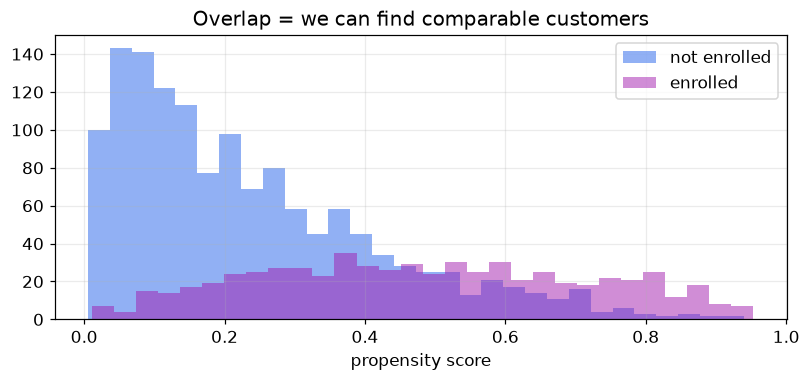

In [4]:
X = df[["prior_spend","tenure_months"]].values
ps = LogisticRegression(max_iter=1000).fit(X, df.enrolled).predict_proba(X)[:,1]
fig, ax = plt.subplots(figsize=(7.5,3.6))
ax.hist(ps[df.enrolled==0], bins=30, alpha=0.5, color=BL, label="not enrolled")
ax.hist(ps[df.enrolled==1], bins=30, alpha=0.5, color=FU, label="enrolled")
ax.set_xlabel("propensity score"); ax.set_title("Overlap = we can find comparable customers"); ax.legend()
plt.tight_layout(); plt.show()

## Challenge 4 &middot; Inverse-probability weighting
Weight treated by 1/p and controls by 1/(1-p) to build a pseudo-population where treatment is unconfounded.

In [5]:
w = np.where(df.enrolled==1, 1/ps, 1/(1-ps))
ipw = (np.sum(w*df.enrolled*df.spend)/np.sum(w*df.enrolled)
       - np.sum(w*(1-df.enrolled)*df.spend)/np.sum(w*(1-df.enrolled)))
print(f"IPW estimate = ${ipw:.1f}   (regression ${reg.params['enrolled']:.0f}, true ${TRUE})")

IPW estimate = $100.9   (regression $117, true $120)


## Challenge 5 &middot; Control for a collider
A collider is caused by both treatment and outcome. Adding it as a control OPENS a false path and distorts the estimate, proof that more controls is not always better.

In [6]:
rng = np.random.default_rng(0)
df["loyalty_points"] = (0.02*df.spend + 8*df.enrolled + rng.normal(0,3,len(df))).round(1)  # caused by BOTH
good = smf.ols("spend ~ enrolled + prior_spend + tenure_months", data=df).fit().params["enrolled"]
bad  = smf.ols("spend ~ enrolled + prior_spend + tenure_months + loyalty_points", data=df).fit().params["enrolled"]
print(f"adjusting for confounders only          = ${good:.1f}  (true ${TRUE})")
print(f"ALSO controlling the collider (points)  = ${bad:.1f}  <- distorted")
print("The DAG, not the data, tells you loyalty_points is a collider to leave out.")

adjusting for confounders only          = $117.1  (true $120)
ALSO controlling the collider (points)  = $55.1  <- distorted
The DAG, not the data, tells you loyalty_points is a collider to leave out.
